# 01 — Phân tích dữ liệu khám phá

## Định nghĩa bài toán nghiệp vụ

- **Quyết định:** hỗ trợ chuyên viên phân tích cổ phiếu rà soát kịch bản return 5 phiên sau khi thị trường đóng cửa; output không phải giao dịch tự động hay price target.
- **Đơn vị dự báo:** một cặp ticker-date. Model dự báo cumulative log-return từ giá đóng cửa ngày `t` đến giá đóng cửa ngày `t+5`.
- **Population:** dữ liệu OHLCV ngày của cổ phiếu niêm yết thanh khoản, có ít nhất 500 phiên đúng thứ tự. Run minh hoạ kiểm chứng workflow trên ticker cấu hình (hiện là VIC, mã provider `VIC.VN`) từ năm 2018.
- **Chi phí sai lệch:** overprediction có thể tạo long exposure không cần thiết, vì vậy directional false positive được theo dõi cùng MAE đối xứng. Underprediction chủ yếu thể hiện phần tăng giá bị bỏ lỡ.
- **Baseline:** zero-return và return 5 phiên gần nhất.
- **Input bị loại:** định danh date/ticker và mọi giá trị quan sát sau khi đóng cửa ngày `t`. OHLCV là dữ liệu thị trường, không phải thuộc tính cá nhân nhạy cảm.

Dataset chỉ hỗ trợ dự báo return lịch sử và backtesting. Dataset không chứa ý định giao dịch, ràng buộc danh mục, fundamentals hay label chứng minh mức độ phù hợp đầu tư.

In [1]:
import json
import os
import warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MPL_CONFIG = ROOT / ".matplotlib"
MPL_CONFIG.mkdir(exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(MPL_CONFIG)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
# Run minh hoạ mặc định dùng VIC; pipeline nhận ticker khác qua config/CLI.
DATA_PATH = ROOT / "data" / "raw" / "VIC_VN.csv"
REPORT_DIR = ROOT / "evaluation"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
np.random.seed(SEED)

In [2]:
raw = pd.read_csv(DATA_PATH, parse_dates=["date"])
required = ["date", "open", "high", "low", "close", "volume"]
audit = {
    "rows": len(raw),
    "start": raw["date"].min().date().isoformat(),
    "end": raw["date"].max().date().isoformat(),
    "duplicate_dates": int(raw["date"].duplicated().sum()),
    "missing_cells": int(raw[required].isna().sum().sum()),
    "non_positive_prices": int((raw[["open", "high", "low", "close"]] <= 0).sum().sum()),
    "negative_volume": int((raw["volume"] < 0).sum()),
}
audit

{'rows': 2246,
 'start': '2018-01-01',
 'end': '2026-08-14',
 'duplicate_dates': 0,
 'missing_cells': 0,
 'non_positive_prices': 0,
 'negative_volume': 0}

In [3]:
returns = np.log(raw["close"] / raw["close"].shift(1))
target_5d = np.log(raw["close"].shift(-5) / raw["close"])
summary = pd.DataFrame({"close": raw["close"], "return_1d": returns, "target_return_5d": target_5d}).describe().T
summary

,count,mean,std,min,25%,50%,75%,max
close,2246.0,51809.521760,42380.609352,19950.000000,28050.000000,43388.888672,51111.109375,230500.000000
return_1d,2245.0,0.000870,0.021526,-0.091196,-0.006101,0.000000,0.006154,0.134784
target_return_5d,2241.0,0.004385,0.053246,-0.232805,-0.020107,0.000000,0.023531,0.246463


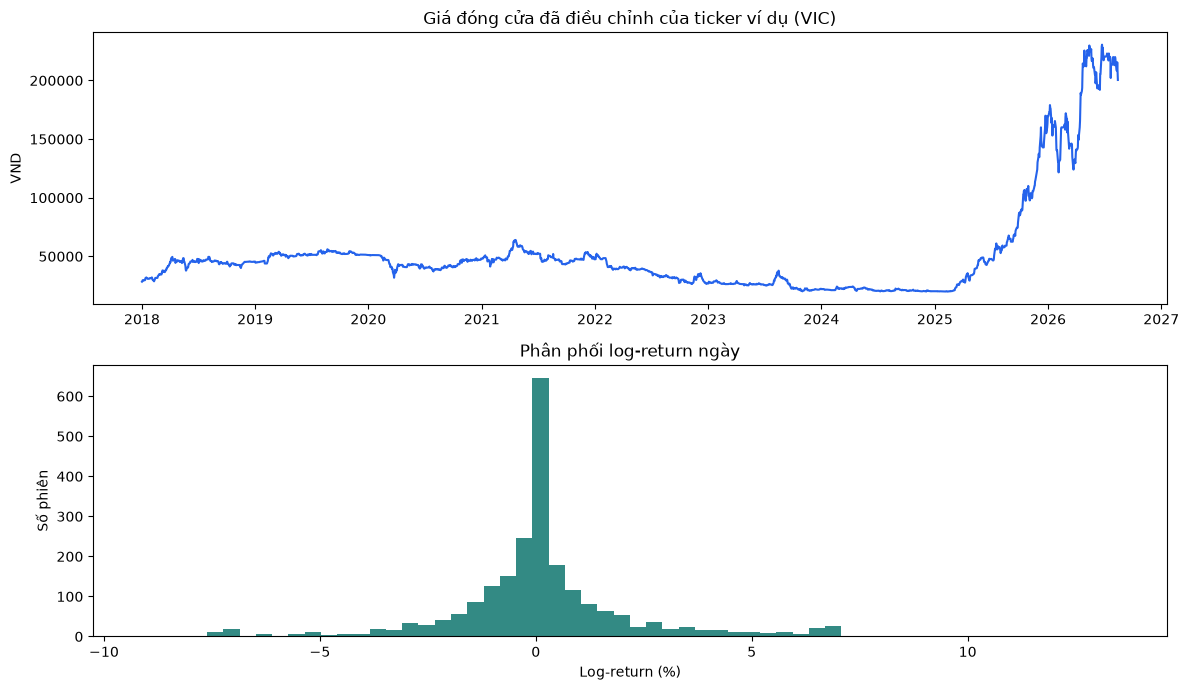

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
axes[0].plot(raw["date"], raw["close"], color="#2563eb")
axes[0].set(title="Giá đóng cửa đã điều chỉnh của ticker ví dụ (VIC)", ylabel="VND")
axes[1].hist(returns.dropna() * 100, bins=60, color="#0f766e", alpha=.85)
axes[1].set(title="Phân phối log-return ngày", xlabel="Log-return (%)", ylabel="Số phiên")
plt.tight_layout()
plt.show()

In [5]:
q1, q3 = returns.quantile([.25, .75])
iqr = q3 - q1
outliers = int(((returns < q1 - 3 * iqr) | (returns > q3 + 3 * iqr)).sum())
conclusion = {
    "target_choice": "cumulative log-return 5 phiên; giá đóng cửa thô không dừng và không phù hợp làm target trực tiếp",
    "outlier_sessions_3iqr": outliers,
    "leakage_action": "tạo target từ giá đóng cửa tương lai, sau đó loại target/date khỏi production feature",
    "population_action": "từ chối chuỗi sai thứ tự, trùng lặp, giá không dương hoặc ngắn hơn 500 phiên",
}
print(json.dumps(conclusion, indent=2))

{
  "target_choice": "cumulative log-return 5 phi\u00ean; gi\u00e1 \u0111\u00f3ng c\u1eeda th\u00f4 kh\u00f4ng d\u1eebng v\u00e0 kh\u00f4ng ph\u00f9 h\u1ee3p l\u00e0m target tr\u1ef1c ti\u1ebfp",
  "outlier_sessions_3iqr": 174,
  "leakage_action": "t\u1ea1o target t\u1eeb gi\u00e1 \u0111\u00f3ng c\u1eeda t\u01b0\u01a1ng lai, sau \u0111\u00f3 lo\u1ea1i target/date kh\u1ecfi production feature",
  "population_action": "t\u1eeb ch\u1ed1i chu\u1ed7i sai th\u1ee9 t\u1ef1, tr\u00f9ng l\u1eb7p, gi\u00e1 kh\u00f4ng d\u01b0\u01a1ng ho\u1eb7c ng\u1eafn h\u01a1n 500 phi\u00ean"
}
